# ONNX Semantic Security Engine -- Full 15-Class Training

**Dataset:** CSE-CIC-IDS2018 (all 10 days, parquet format)  
**Model:** ThreatMLP -- 256 -> 128 -> 64 -> 15 classes with BatchNorm  
**Pipeline:**
1. Load all 10 parquet files, drop leakage cols, resample
2. Train MLP with LR scheduler + best-model checkpointing (30 epochs)
3. Export FP32 ONNX, Validate PyTorch == ONNX (RQ1)
4. INT8 static quantization, size/latency/F1 comparison (RQ2)
5. Cross-dataset evaluation on ToN-IoT (RQ3)

**Target:** Macro-F1 >= 0.80 across all 15 classes  
**Download after run:** threat_mlp.pth, label_encoder.joblib, standard_scaler.joblib, threat_mlp_fp32.onnx, threat_mlp_int8.onnx

In [4]:
!pip install -q onnx onnxscript onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 11.4 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 88.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 14.1 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn as nn

# Widened architecture: 256 -> 128 -> 64 -> num_classes
# BatchNorm added after each hidden layer for stable 15-class training
class ThreatMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ThreatMLP, self).__init__()
        self.fc1      = nn.Linear(input_dim, 256)
        self.bn1      = nn.BatchNorm1d(256)
        self.relu1    = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2      = nn.Linear(256, 128)
        self.bn2      = nn.BatchNorm1d(128)
        self.relu2    = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3      = nn.Linear(128, 64)
        self.bn3      = nn.BatchNorm1d(64)
        self.relu3    = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        self.fc4      = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.fc2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.fc3(x))))
        return self.fc4(x)

print("ThreatMLP defined (256->128->64->num_classes with BatchNorm)")


ThreatMLP defined (256->128->64->num_classes with BatchNorm)


In [6]:
import pandas as pd
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import joblib, os, time, glob

# Load all parquet files
parquet_files = glob.glob("/kaggle/input/datasets/dhoogla/csecicids2018/*.parquet", recursive=True)
print(f"Found {len(parquet_files)} parquet files.")
dfs = []
for file in parquet_files:
    print(f"Loading {os.path.basename(file)}...")
    dfs.append(pd.read_parquet(file))
df = pd.concat(dfs, ignore_index=True)
df.columns = df.columns.str.strip()

# Drop leakage columns (IP/port/protocol are dataset-specific identifiers,
# not semantic features -- per Cantone et al. 2024, Paper 6 in lit review)
leakage_cols = ["Timestamp", "Flow ID", "Src IP", "Dst IP", "Src Port", "Dst Port", "Protocol"]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors="ignore")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna().drop_duplicates()
print(f"Raw dataset shape: {df.shape}")
print(df['Label'].value_counts().to_string())

# Resample: cap majority at 100K, oversample minority to 5K
MAX_SAMPLES = 100_000
MIN_SAMPLES = 5_000
resampled_dfs = []
for label, group in df.groupby("Label"):
    n = len(group)
    if n > MAX_SAMPLES:
        resampled_dfs.append(group.sample(n=MAX_SAMPLES, random_state=42))
        print(f"  down {label}: {n} -> {MAX_SAMPLES}")
    elif n < MIN_SAMPLES:
        resampled_dfs.append(group.sample(n=MIN_SAMPLES, replace=True, random_state=42))
        print(f"  up   {label}: {n} -> {MIN_SAMPLES}")
    else:
        resampled_dfs.append(group)
        print(f"  =    {label}: {n}")
df = pd.concat(resampled_dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Resampled dataset shape: {df.shape}")


Found 10 parquet files.
Loading DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet...
Loading Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet...
Loading DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet...
Raw dataset shape: (6320003, 77)
Label
Benign                      4994160
DDoS attacks-LOIC-HTTP       575364
DDOS attack-HOIC             198861
DoS attacks-Hulk             145199
Bot                          144535
Infilteration                113819
SSH-Brutefo

In [7]:
# Encode, split, scale, train
X = df.drop(columns=["Label"]).values
y = df["Label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
print(f"Classes ({num_classes}): {label_encoder.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Fit scaler only on training data to avoid leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# Save test data for later evaluation / ONNX testing
np.save("/kaggle/working/X_test.npy", X_test)
np.save("/kaggle/working/y_test.npy", y_test)

# Convert to PyTorch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test.astype(np.int64))

# T4 supports CUDA (sm_75)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

input_dim = X_train.shape[1]
model = ThreatMLP(input_dim, num_classes).to(device)

# Class weights help with imbalanced attack classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
).astype(np.float32)

criterion = nn.CrossEntropyLoss(
    weight=torch.from_numpy(class_weights).to(device)
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

BATCH_SIZE = 1024

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=4096,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True
)

NUM_EPOCHS = 30
best_f1 = 0.0


def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(device, non_blocking=True)
            outputs = model(bx)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(by.numpy())

    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    return macro_f1, np.array(all_preds), np.array(all_targets)


for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for bx, by in train_loader:
        bx = bx.to(device, non_blocking=True)
        by = by.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(bx)
        loss = criterion(outputs, by)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / n_batches
    scheduler.step(avg_loss)

    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0:
        val_f1, _, _ = evaluate(model, test_loader, device)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "/kaggle/working/threat_mlp_best.pth")

        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Macro-F1: {val_f1:.4f} | "
            f"Best: {best_f1:.4f}"
        )
    else:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

# Load best checkpoint
model.load_state_dict(
    torch.load("/kaggle/working/threat_mlp_best.pth", map_location=device)
)

# Final evaluation
fp32_f1, preds, true_labels = evaluate(model, test_loader, device)

print(f"\nBest Model — Macro-F1: {fp32_f1:.4f}")
print(
    classification_report(
        true_labels,
        preds,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# Save artifacts
torch.save(model.state_dict(), "/kaggle/working/threat_mlp.pth")
joblib.dump(label_encoder, "/kaggle/working/label_encoder.joblib")
joblib.dump(scaler, "/kaggle/working/standard_scaler.joblib")

print("\nModel, scaler, and label encoder saved successfully.")

Classes (15): ['Benign' 'Bot' 'Brute Force -Web' 'Brute Force -XSS' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye'
 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Slowloris'
 'FTP-BruteForce' 'Infilteration' 'SQL Injection' 'SSH-Bruteforce']
Train: 620289, Test: 155073
Device: cuda
GPU: Tesla T4
Epoch 1/30 | Loss: 0.5647
Epoch 2/30 | Loss: 0.3241
Epoch 3/30 | Loss: 0.3041
Epoch 4/30 | Loss: 0.2930
Epoch 5/30 | Loss: 0.2856 | Val Macro-F1: 0.7999 | Best: 0.7999
Epoch 6/30 | Loss: 0.2804
Epoch 7/30 | Loss: 0.2784
Epoch 8/30 | Loss: 0.2741
Epoch 9/30 | Loss: 0.2736
Epoch 10/30 | Loss: 0.2690 | Val Macro-F1: 0.7987 | Best: 0.7999
Epoch 11/30 | Loss: 0.2690
Epoch 12/30 | Loss: 0.2662
Epoch 13/30 | Loss: 0.2649
Epoch 14/30 | Loss: 0.2642
Epoch 15/30 | Loss: 0.2634 | Val Macro-F1: 0.8051 | Best: 0.8051
Epoch 16/30 | Loss: 0.2630
Epoch 17/30 | Loss: 0.2614
Epoch 18/30 | Loss: 0.2611
Epoch 19/30 | Loss: 0.2601
Epoch 20/30 | Loss: 0.2586 |

In [8]:
import onnx
import onnxruntime as ort

# Export FP32 ONNX (move to CPU first)
model.cpu().eval()
dummy = torch.randn(1, input_dim, dtype=torch.float32)
torch.onnx.export(
    model, dummy,
    "/kaggle/working/threat_mlp_fp32.onnx",
    opset_version=17,
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
)
onnx_model = onnx.load("/kaggle/working/threat_mlp_fp32.onnx")
onnx.checker.check_model(onnx_model)
print("FP32 ONNX structure valid")

# RQ1 Semantic Validation: compare PyTorch vs ONNX Runtime predictions
# Per Jajal et al. 2024 (Paper 2), 33% of ONNX conversions fail silently.
ort_session = ort.InferenceSession("/kaggle/working/threat_mlp_fp32.onnx", providers=["CPUExecutionProvider"])
all_match = True
for i in range(20):
    rand_input = np.random.randn(1, input_dim).astype(np.float32)
    with torch.no_grad():
        pt_pred = torch.argmax(model(torch.FloatTensor(rand_input)), dim=1).item()
    onnx_pred = int(np.argmax(ort_session.run(None, {"input": rand_input})[0], axis=1)[0])
    status = "MATCH" if pt_pred == onnx_pred else "MISMATCH"
    if pt_pred != onnx_pred: all_match = False
    print(f"Sample {i+1:2d}: PyTorch={pt_pred}  ONNX={onnx_pred}  {status}")
print("RQ1 PASSED: All samples match" if all_match else "RQ1 FAILED: Mismatch detected")


/tmp/ipykernel_58/3248233741.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0708 07:31:53.553000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ThreatMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ThreatMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
FP32 ONNX structure valid
Sample  1: PyTorch=0  ONNX=0  MATCH
Sample  2: PyTorch=8  ONNX=8  MATCH
Sample  3: PyTorch=0  ONNX=0  MATCH
Sample  4: PyTorch=0  ONNX=0  MATCH
Sample  5: PyTorch=0  ONNX=0  MATCH
Sample  6: PyTorch=0  ONNX=0  MATCH
Sample  7: PyTorch=0  ONNX=0  MATCH
Sample  8: PyTorch=12  ONNX=12  MATCH
Sample  9: PyTorch=8  ONNX=8  MATCH
Sample 10: PyTorch=12  ONNX=12  MATCH
Sample 11: PyTorch=0  ONNX=0  MATCH
Sample 12: PyTorch=12  ONNX=12  MATCH
Sample 13: PyTorch=12  ONNX=12  MATCH
Sample 14: PyTorch=0  ONNX=0  MATCH
Sample 15: PyTorch=0  ONNX=0  MATCH
Sample 16: PyTorch=0  ONNX=0  MATCH
Sample 17: PyTorch=7  ONNX=7  MATCH
Sample 18: PyTorch=12  ONNX=12  MATCH
Sample 19: PyTorch=0  ONNX=0  MATCH
Sample 20: PyTorch=12  ONNX=12  MATCH
RQ1 PASSED: All samples match


In [10]:
from onnxruntime.quantization import quantize_static, QuantType, QuantFormat, CalibrationDataReader

class CICCalibrationReader(CalibrationDataReader):
    def __init__(self, X_cal):
        self.data = [X_cal[i:i+1].astype(np.float32) for i in range(len(X_cal))]
        self.idx = 0
    def get_next(self):
        if self.idx >= len(self.data): return None
        result = {"input": self.data[self.idx]}
        self.idx += 1
        return result
    def rewind(self): self.idx = 0

cal_reader = CICCalibrationReader(X_train[:1000])
quantize_static(
    model_input="/kaggle/working/threat_mlp_fp32.onnx",
    model_output="/kaggle/working/threat_mlp_int8.onnx",
    calibration_data_reader=cal_reader,
    quant_format=QuantFormat.QDQ,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QUInt8,
)
print("INT8 model saved")


INT8 model saved


In [11]:
import json

def benchmark_model(model_path, X_data, y_data, label, n_runs=1000):
    sess = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    total_size = os.path.getsize(model_path)
    data_file = model_path + '.data'
    if os.path.exists(data_file): total_size += os.path.getsize(data_file)
    size_mb = total_size / (1024 * 1024)
    sample = X_data[:1].astype(np.float32)
    for _ in range(10):
        sess.run(None, {"input": sample})
    start = time.perf_counter()
    for i in range(n_runs):
        sess.run(None, {"input": X_data[i:i+1].astype(np.float32)})
    elapsed_ms = (time.perf_counter() - start) / n_runs * 1000
    all_preds = []
    for i in range(0, len(X_data), 512):
        batch = X_data[i:i+512].astype(np.float32)
        all_preds.extend(np.argmax(sess.run(None, {"input": batch})[0], axis=1))
    macro_f1 = f1_score(y_data, all_preds, average="macro")
    print(f"\n{label}  |  Size: {size_mb:.3f} MB  |  Latency: {elapsed_ms:.3f} ms/sample  |  F1: {macro_f1:.4f}")
    return {"model": label, "size_mb": size_mb, "latency_ms": elapsed_ms, "macro_f1": macro_f1}

X_test_bm = np.load("/kaggle/working/X_test.npy")
y_test_bm = np.load("/kaggle/working/y_test.npy")
fp32_results = benchmark_model("/kaggle/working/threat_mlp_fp32.onnx", X_test_bm, y_test_bm, "FP32")
int8_results = benchmark_model("/kaggle/working/threat_mlp_int8.onnx", X_test_bm, y_test_bm, "INT8")

size_pct = (1 - int8_results['size_mb'] / fp32_results['size_mb']) * 100
lat_pct  = (1 - int8_results['latency_ms'] / fp32_results['latency_ms']) * 100
f1_delta = int8_results['macro_f1'] - fp32_results['macro_f1']
print("\nRQ2 SUMMARY")
print(f"Size:    {fp32_results['size_mb']:.3f} -> {int8_results['size_mb']:.3f} MB  ({size_pct:.1f}% smaller)")
print(f"Latency: {fp32_results['latency_ms']:.3f} -> {int8_results['latency_ms']:.3f} ms")
print(f"F1:      {fp32_results['macro_f1']:.4f} -> {int8_results['macro_f1']:.4f}  (delta={f1_delta:+.4f})")

with open("/kaggle/working/quantization_comparison.json", "w") as f:
    json.dump({"fp32": fp32_results, "int8": int8_results}, f, indent=2)
print("Results saved to quantization_comparison.json")



FP32  |  Size: 0.238 MB  |  Latency: 0.028 ms/sample  |  F1: 0.8134

INT8  |  Size: 0.065 MB  |  Latency: 0.036 ms/sample  |  F1: 0.8003

RQ2 SUMMARY
Size:    0.238 -> 0.065 MB  (72.7% smaller)
Latency: 0.028 -> 0.036 ms
F1:      0.8134 -> 0.8003  (delta=-0.0131)
Results saved to quantization_comparison.json


In [12]:
# Cross-Dataset Generalization on ToN-IoT (RQ3)
# Train on CIC-IDS2018, test on ToN-IoT without retraining.
# Feature alignment per Sarhan et al. 2021 (Paper 7 in our lit review).

toniot_path = "/kaggle/input/datasets/dhoogla/nftoniotv2/NF-ToN-IoT-V2.parquet"
df_ton = pd.read_parquet(toniot_path).sample(n=500_000, random_state=42).reset_index(drop=True)
df_ton.columns = df_ton.columns.str.strip()
print(f"ToN-IoT shape: {df_ton.shape}")
print(df_ton['Attack'].value_counts().to_string())

FEATURE_MAP = {
    "FLOW_DURATION_MILLISECONDS": "Flow Duration",
    "IN_PKTS":                    "Total Fwd Packets",
    "OUT_PKTS":                   "Total Backward Packets",
    "IN_BYTES":                   "Fwd Packets Length Total",
    "OUT_BYTES":                  "Bwd Packets Length Total",
    "MAX_IP_PKT_LEN":             "Fwd Packet Length Max",
    "MIN_IP_PKT_LEN":             "Fwd Packet Length Min",
    "LONGEST_FLOW_PKT":           "Packet Length Max",
    "SHORTEST_FLOW_PKT":          "Packet Length Min",
    "SRC_TO_DST_SECOND_BYTES":    "Flow Bytes/s",
    "SRC_TO_DST_AVG_THROUGHPUT":  "Fwd Header Length",
    "DST_TO_SRC_AVG_THROUGHPUT":  "Bwd Header Length",
    "TCP_FLAGS":                  "Fwd PSH Flags",
    "TCP_WIN_MAX_IN":              "Init Fwd Win Bytes",
    "TCP_WIN_MAX_OUT":             "Init Bwd Win Bytes",
    "RETRANSMITTED_IN_PKTS":      "Fwd Avg Packets/Bulk",
    "RETRANSMITTED_OUT_PKTS":     "Bwd Avg Packets/Bulk",
    "RETRANSMITTED_IN_BYTES":     "Fwd Avg Bytes/Bulk",
    "RETRANSMITTED_OUT_BYTES":    "Bwd Avg Bytes/Bulk",
    "NUM_PKTS_UP_TO_128_BYTES":   "Subflow Fwd Packets",
    "NUM_PKTS_1024_TO_1514_BYTES": "Subflow Bwd Packets",
}

cic_features = df.drop(columns=['Label']).columns.tolist()
reverse_map = {v: k for k, v in FEATURE_MAP.items()}
X_ton = np.zeros((len(df_ton), len(cic_features)), dtype=np.float64)
matched, unmatched = [], []
for i, cic_feat in enumerate(cic_features):
    if cic_feat in reverse_map and reverse_map[cic_feat] in df_ton.columns:
        ton_col = reverse_map[cic_feat]
        values = pd.to_numeric(df_ton[ton_col], errors='coerce').fillna(0).values
        if ton_col == "FLOW_DURATION_MILLISECONDS": values = values * 1000
        X_ton[:, i] = values
        matched.append(f"{cic_feat} <- {ton_col}")
    else:
        unmatched.append(cic_feat)
print(f"Matched features: {len(matched)} / {len(cic_features)}")
for m in matched: print(f'  {m}')
print(f"Zero-filled: {len(unmatched)}")

LABEL_MAP = {
    "benign": "Benign", "password": "FTP-BruteForce",
    "dos": "DoS attacks-Hulk", "ddos": "DDoS attacks-LOIC-HTTP",
    "injection": "SQL Injection", "xss": "Brute Force -XSS",
    "backdoor": "Infilteration", "scanning": "Infilteration",
    "ransomware": "Infilteration", "mitm": "Infilteration",
}
df_ton['mapped_label'] = (
    df_ton['Attack'].astype(str).str.lower().str.strip()
    .map(LABEL_MAP).fillna("Unknown-Attack")
)
print(df_ton['mapped_label'].value_counts().to_string())

known_labels = set(label_encoder.classes_)
mask = np.array([l in known_labels for l in df_ton['mapped_label'].values])
X_ton_known = X_ton[mask]
y_ton_known = label_encoder.transform(df_ton['mapped_label'].values[mask])
print(f"Filtered: {len(X_ton_known)}, Dropped: {(~mask).sum()}")

X_ton_known = np.nan_to_num(np.clip(X_ton_known, -1e10, 1e10).astype(np.float32))
X_ton_scaled = np.nan_to_num(scaler.transform(X_ton_known)).astype(np.float32)

sess = ort.InferenceSession("/kaggle/working/threat_mlp_fp32.onnx", providers=["CPUExecutionProvider"])
ton_preds = []
for i in range(0, len(X_ton_scaled), 512):
    out = sess.run(None, {"input": X_ton_scaled[i:i+512]})[0]
    ton_preds.extend(np.argmax(out, axis=1))
ton_preds = np.array(ton_preds)
ton_f1 = f1_score(y_ton_known, ton_preds, average="macro")

print("\nRQ3 CROSS-DATASET REPORT")
print(f"CIC-IDS2018 (in-distribution)   Macro-F1: {fp32_results['macro_f1']:.4f}")
print(f"ToN-IoT (out-of-distribution)   Macro-F1: {ton_f1:.4f}")
print(f"F1 Drop: {fp32_results['macro_f1'] - ton_f1:.4f}")
print(f"Features matched: {len(matched)} / {len(cic_features)}")

unique_labels = sorted(np.unique(np.concatenate([y_ton_known, ton_preds])))
print(classification_report(y_ton_known, ton_preds,
    labels=unique_labels,
    target_names=[label_encoder.classes_[i] for i in unique_labels],
    zero_division=0))

cross_results = {
    "cic_ids2018_f1": fp32_results["macro_f1"],
    "toniot_f1": float(ton_f1),
    "f1_drop": float(fp32_results["macro_f1"] - ton_f1),
    "toniot_samples_evaluated": int(len(X_ton_known)),
    "features_matched": len(matched),
    "feature_mapping_used": FEATURE_MAP,
}
with open("/kaggle/working/cross_dataset_comparison.json", "w") as f:
    json.dump(cross_results, f, indent=2)
print("Cross-dataset results saved")


ToN-IoT shape: (500000, 43)
Attack
Benign        137422
scanning      113937
xss            93159
ddos           66636
password       37753
dos            25098
injection      24950
backdoor         624
mitm             304
ransomware       117
Matched features: 21 / 76
  Flow Duration <- FLOW_DURATION_MILLISECONDS
  Total Fwd Packets <- IN_PKTS
  Total Backward Packets <- OUT_PKTS
  Fwd Packets Length Total <- IN_BYTES
  Bwd Packets Length Total <- OUT_BYTES
  Fwd Packet Length Max <- MAX_IP_PKT_LEN
  Fwd Packet Length Min <- MIN_IP_PKT_LEN
  Flow Bytes/s <- SRC_TO_DST_SECOND_BYTES
  Fwd PSH Flags <- TCP_FLAGS
  Fwd Header Length <- SRC_TO_DST_AVG_THROUGHPUT
  Bwd Header Length <- DST_TO_SRC_AVG_THROUGHPUT
  Packet Length Min <- SHORTEST_FLOW_PKT
  Packet Length Max <- LONGEST_FLOW_PKT
  Fwd Avg Bytes/Bulk <- RETRANSMITTED_IN_BYTES
  Fwd Avg Packets/Bulk <- RETRANSMITTED_IN_PKTS
  Bwd Avg Bytes/Bulk <- RETRANSMITTED_OUT_BYTES
  Bwd Avg Packets/Bulk <- RETRANSMITTED_OUT_PKTS
  Subflow 

In [15]:
!pip install -q onnxconverter-common matplotlib seaborn

import onnx
from onnxconverter_common import float16
import json
import os, time
import numpy as np
import onnxruntime as ort
from sklearn.metrics import f1_score

# Helper specifically for FP16 evaluation
def benchmark_fp16(model_path, X_data, y_data, label, n_runs=1000):
    sess = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    total_size = os.path.getsize(model_path)
    if os.path.exists(model_path + '.data'): 
        total_size += os.path.getsize(model_path + '.data')
    size_mb = total_size / (1024 * 1024)
    
    # Force casting to float16
    sample = X_data[:1].astype(np.float16)
    for _ in range(10): sess.run(None, {"input": sample})
        
    start = time.perf_counter()
    for i in range(n_runs): sess.run(None, {"input": X_data[i:i+1].astype(np.float16)})
    elapsed_ms = (time.perf_counter() - start) / n_runs * 1000
    
    all_preds = []
    for i in range(0, len(X_data), 512):
        batch = X_data[i:i+512].astype(np.float16)
        all_preds.extend(np.argmax(sess.run(None, {"input": batch})[0], axis=1))
        
    macro_f1 = f1_score(y_data, all_preds, average="macro")
    return {"model": label, "size_mb": size_mb, "latency_ms": elapsed_ms, "macro_f1": macro_f1}

# Task 4: FP16 Quantization
print("Converting FP32 model to FP16...")
model_fp32 = onnx.load("/kaggle/working/threat_mlp_fp32.onnx")
model_fp16 = float16.convert_float_to_float16(model_fp32)
onnx.save(model_fp16, "/kaggle/working/threat_mlp_fp16.onnx")
print("FP16 model saved.")

# Benchmark using the new FP16-compatible function
fp16_results = benchmark_fp16("/kaggle/working/threat_mlp_fp16.onnx", X_test_bm, y_test_bm, "FP16")

print("\n--- UPDATED RQ2 SUMMARY (FP32 vs FP16 vs INT8) ---")
print(f"Size (MB):    FP32={fp32_results['size_mb']:.3f} | FP16={fp16_results['size_mb']:.3f} | INT8={int8_results['size_mb']:.3f}")
print(f"Latency (ms): FP32={fp32_results['latency_ms']:.3f} | FP16={fp16_results['latency_ms']:.3f} | INT8={int8_results['latency_ms']:.3f}")
print(f"Macro-F1:     FP32={fp32_results['macro_f1']:.4f} | FP16={fp16_results['macro_f1']:.4f} | INT8={int8_results['macro_f1']:.4f}")

# Save the updated comparison
with open("/kaggle/working/quantization_comparison_full.json", "w") as f:
    json.dump({"fp32": fp32_results, "fp16": fp16_results, "int8": int8_results}, f, indent=2)


Converting FP32 model to FP16...
FP16 model saved.


/tmp/ipykernel_58/704222821.py:29: RuntimeWarning: overflow encountered in cast
  batch = X_data[i:i+512].astype(np.float16)



--- UPDATED RQ2 SUMMARY (FP32 vs FP16 vs INT8) ---
Size (MB):    FP32=0.238 | FP16=0.119 | INT8=0.065
Latency (ms): FP32=0.028 | FP16=0.019 | INT8=0.036
Macro-F1:     FP32=0.8134 | FP16=0.8134 | INT8=0.8003


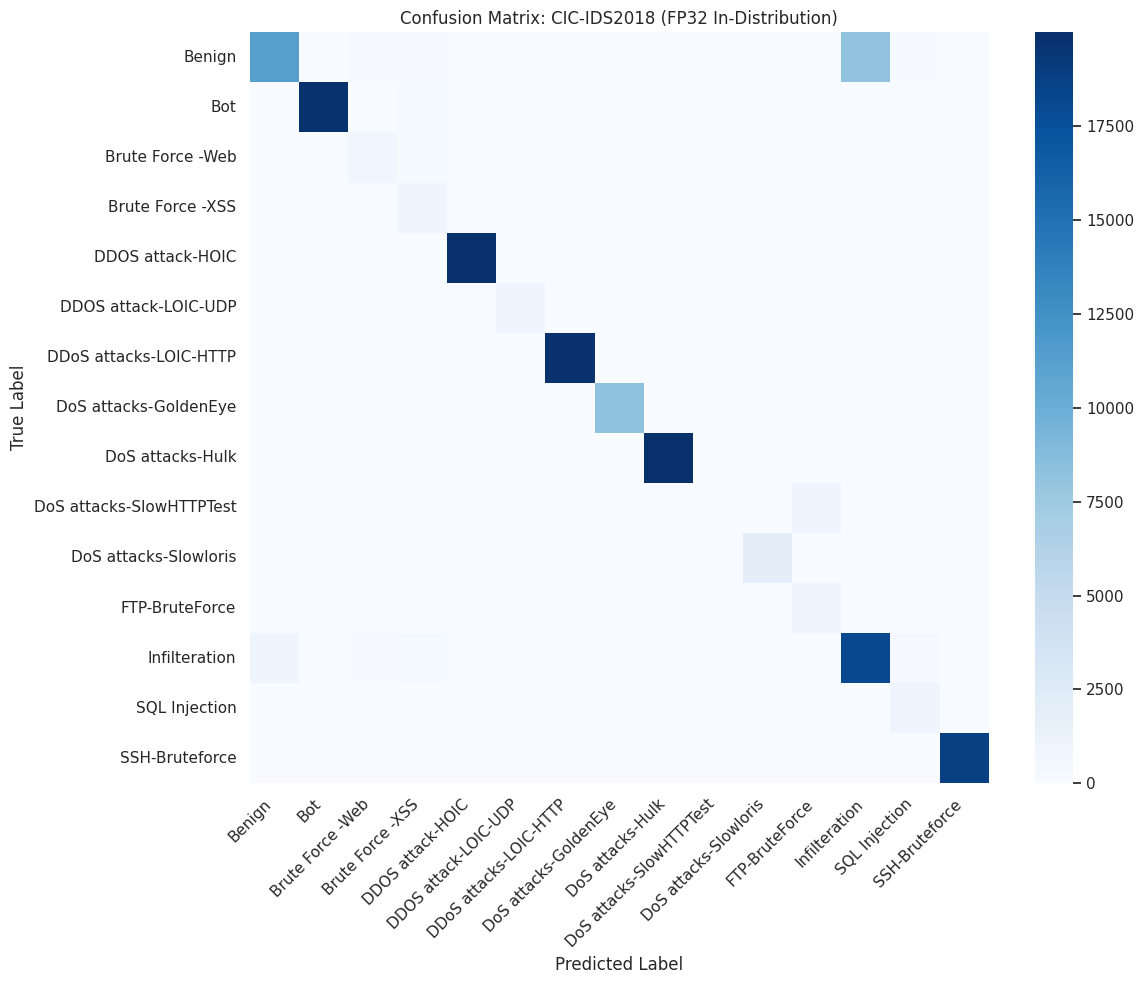

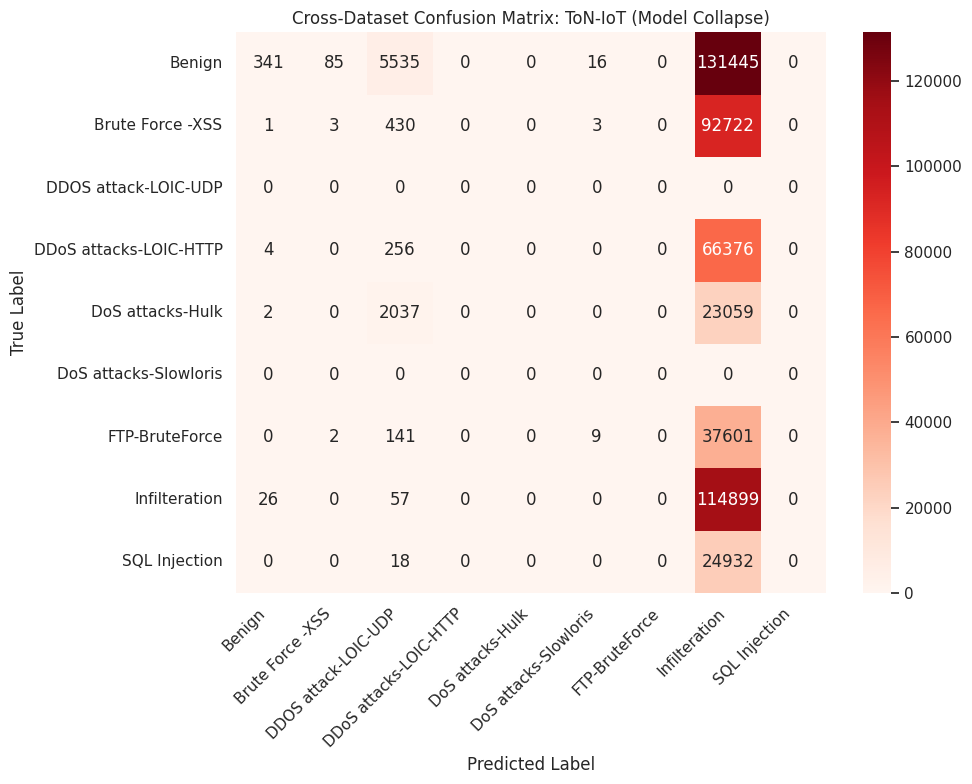

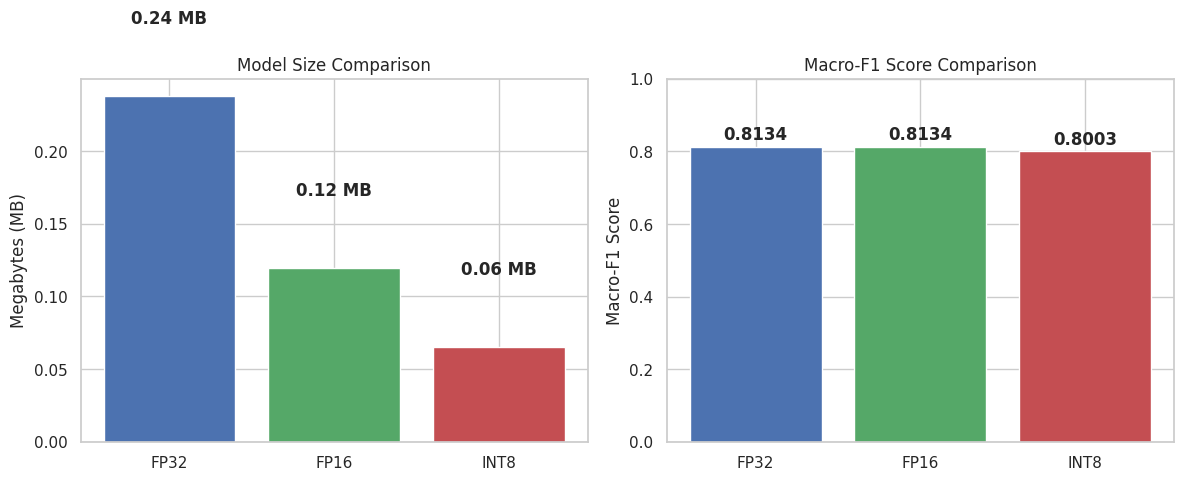


✅ All 3 plots successfully saved as PNG files in the output directory!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import onnxruntime as ort

# Set plot style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Confusion Matrix for CIC-IDS2018 (In-distribution)
# ---------------------------------------------------------
sess = ort.InferenceSession("/kaggle/working/threat_mlp_fp32.onnx", providers=["CPUExecutionProvider"])
all_preds = []
for i in range(0, len(X_test_bm), 512):
    batch = X_test_bm[i:i+512].astype(np.float32)
    all_preds.extend(np.argmax(sess.run(None, {"input": batch})[0], axis=1))

cm_cic = confusion_matrix(y_test_bm, all_preds)
plt.figure(figsize=(12, 10))
# Using annot=False here because 15x15 grids get too cluttered with text
sns.heatmap(cm_cic, annot=False, cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix: CIC-IDS2018 (FP32 In-Distribution)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_cic.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 2: Confusion Matrix for ToN-IoT (Cross-dataset)
# ---------------------------------------------------------
# Force a 15x15 matrix first by passing all possible labels
all_possible_labels = np.arange(len(label_encoder.classes_))
cm_ton = confusion_matrix(y_ton_known, ton_preds, labels=all_possible_labels)

plt.figure(figsize=(10, 8))

# Filter out empty classes for cleaner visualization
unique_labels_idx = sorted(np.unique(np.concatenate([y_ton_known, ton_preds])))
cm_ton_filtered = cm_ton[np.ix_(unique_labels_idx, unique_labels_idx)]
labels_present = [label_encoder.classes_[i] for i in unique_labels_idx]

sns.heatmap(cm_ton_filtered, annot=True, fmt='d', cmap='Reds', xticklabels=labels_present, yticklabels=labels_present)
plt.title('Cross-Dataset Confusion Matrix: ToN-IoT (Model Collapse)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_toniot.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 3: Quantization Comparison Bar Charts
# ---------------------------------------------------------
labels = ['FP32', 'FP16', 'INT8']
sizes = [fp32_results['size_mb'], fp16_results['size_mb'], int8_results['size_mb']]
f1_scores = [fp32_results['macro_f1'], fp16_results['macro_f1'], int8_results['macro_f1']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Size
ax1.bar(labels, sizes, color=['#4C72B0', '#55A868', '#C44E52'])
ax1.set_title('Model Size Comparison')
ax1.set_ylabel('Megabytes (MB)')
for i, v in enumerate(sizes):
    ax1.text(i, v + 0.05, f"{v:.2f} MB", ha='center', fontweight='bold')

# Plot F1 Score
ax2.bar(labels, f1_scores, color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('Macro-F1 Score Comparison')
ax2.set_ylabel('Macro-F1 Score')
ax2.set_ylim(0, 1.0)
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/quantization_comparison.png', dpi=300)
plt.show()

print("\n✅ All 3 plots successfully saved as PNG files in the output directory!")
